In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
datos = pd.read_csv("ventas.csv")

In [ ]:
datos.info()
datos.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_venta         500 non-null    int64  
 1   fecha_venta      499 non-null    object 
 2   id_producto      500 non-null    object 
 3   producto         500 non-null    object 
 4   categoria        450 non-null    object 
 5   region           500 non-null    object 
 6   vendedor         500 non-null    object 
 7   cantidad         500 non-null    int64  
 8   precio_unitario  446 non-null    object 
 9   descuento_pct    433 non-null    float64
 10  canal_venta      380 non-null    object 
dtypes: float64(1), int64(2), object(8)
memory usage: 43.1+ KB


,id_venta,cantidad,descuento_pct
count,500.000000,500.000000,433.000000
mean,250.500000,24.416000,14.399538
std,144.481833,15.473001,10.165742
min,1.000000,-10.000000,0.000000
25%,125.750000,12.000000,5.000000
50%,250.500000,25.000000,15.000000
75%,375.250000,37.250000,25.000000
max,500.000000,50.000000,30.000000


In [ ]:
# Convert 'fecha_venta' to datetime and 'precio_unitario' to numeric
datos_limpios = datos.copy()
datos_limpios['fecha_venta'] = pd.to_datetime(datos_limpios['fecha_venta'], errors='coerce')
datos_limpios['precio_unitario'] = pd.to_numeric(datos_limpios['precio_unitario'], errors='coerce')

# Filter out rows with non-positive 'cantidad'
datos_limpios = datos_limpios[datos_limpios['cantidad'] > 0]

# Calculate 'monto'
datos_limpios['monto'] = datos_limpios['cantidad'] * datos_limpios['precio_unitario']

# Drop rows with any remaining NaN values after conversions and calculations
datos_limpios = datos_limpios.dropna()

# Create 'fecha' column
datos_limpios['fecha'] = datos_limpios['fecha_venta'].dt.date

datos_limpios.info()
datos_limpios.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 31 entries, 0 to 467
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id_venta         31 non-null     int64         
 1   fecha_venta      31 non-null     datetime64[ns]
 2   id_producto      31 non-null     object        
 3   producto         31 non-null     object        
 4   categoria        31 non-null     object        
 5   region           31 non-null     object        
 6   vendedor         31 non-null     object        
 7   cantidad         31 non-null     int64         
 8   precio_unitario  31 non-null     float64       
 9   descuento_pct    31 non-null     float64       
 10  canal_venta      31 non-null     object        
 11  monto            31 non-null     float64       
 12  fecha            31 non-null     object        
dtypes: datetime64[ns](1), float64(3), int64(2), object(7)
memory usage: 3.4+ KB


,id_venta,fecha_venta,cantidad,precio_unitario,descuento_pct,monto
count,31.000000,31,31.000000,31.000000,31.000000,31.000000
mean,237.580645,2024-07-19 22:27:05.806451712,28.225806,2974.193548,12.903226,95683.870968
min,1.000000,2024-01-08 00:00:00,1.000000,100.000000,0.000000,500.000000
25%,146.500000,2024-04-04 00:00:00,19.000000,250.000000,5.000000,4900.000000
50%,236.000000,2024-08-03 00:00:00,30.000000,1200.000000,10.000000,38400.000000
75%,299.500000,2024-12-03 12:00:00,40.500000,5750.000000,20.000000,153000.000000
max,468.000000,2024-12-11 00:00:00,49.000000,8000.000000,30.000000,392000.000000
std,134.737714,NaN,14.474598,3250.176174,10.390235,117517.159305


In [24]:
faltantes = datos.isna().sum().reset_index()
faltantes.columns = ['columna', 'valores_faltantes']
print(faltantes)

            columna  valores_faltantes
0          id_venta                  0
1       fecha_venta                  1
2       id_producto                  0
3          producto                  0
4         categoria                 50
5            region                  0
6          vendedor                  0
7          cantidad                  0
8   precio_unitario                 54
9     descuento_pct                 67
10      canal_venta                120


In [28]:
import unicodedata
import re

# Initialize datos_limpios from the original datos DataFrame
datos_limpios = datos.copy()

# Date conversion (fecha_venta comes in two formats "dd/mm/aaaa" and "aaaa-mm-dd")
# pd.to_datetime is robust and 'infer_datetime_format=True' helps handle mixed date formats.
# 'errors=coerce' will turn unparseable dates into NaT (Not a Time).
datos_limpios['fecha_venta'] = pd.to_datetime(datos_limpios['fecha_venta'], errors='coerce')

# Helper function for str_squish functionality (remove extra spaces and strip)
def str_squish_python(text):
    if not isinstance(text, str):
        return text # Return as is for non-string types (e.g., NaN)
    return re.sub(r'\s+', ' ', text).strip()

# Standardize text to avoid duplicates due to case sensitivity and extra spaces
datos_limpios['producto'] = datos_limpios['producto'].astype(str).apply(str_squish_python).str.title()

# Handle 'categoria' NaNs and standardize text
datos_limpios['categoria'] = datos_limpios['categoria'].fillna("Sin Categoria")
datos_limpios['categoria'] = datos_limpios['categoria'].astype(str).apply(str_squish_python).str.title()

datos_limpios['region'] = datos_limpios['region'].astype(str).apply(str_squish_python).str.title()

# Remove accents from 'vendedor' to treat "Ana Lopez" and "Ana López" as the same
def remove_accents(text):
    if not isinstance(text, str):
        return text # Return as is for non-string types (e.g., NaN)
    return ''.join(c for c in unicodedata.normalize('NFD', text) if unicodedata.category(c) != 'Mn')

datos_limpios['vendedor'] = datos_limpios['vendedor'].apply(remove_accents)
datos_limpios['vendedor'] = datos_limpios['vendedor'].astype(str).apply(str_squish_python).str.title()

# Handle 'canal_venta' NaNs and standardize text
datos_limpios['canal_venta'] = datos_limpios['canal_venta'].fillna("No Especificado")
datos_limpios['canal_venta'] = datos_limpios['canal_venta'].astype(str).apply(str_squish_python).str.title()

# Convert 'precio_unitario' from text (some values have "$") to numeric
# First, convert to string to handle potential non-string types and then remove '$'
datos_limpios['precio_unitario'] = datos_limpios['precio_unitario'].astype(str).str.replace('$', '', regex=False)
datos_limpios['precio_unitario'] = pd.to_numeric(datos_limpios['precio_unitario'], errors='coerce')

# If 'descuento_pct' is empty, it's taken as 0%
datos_limpios['descuento_pct'] = datos_limpios['descuento_pct'].fillna(0)

# Create variables for analysis
datos_limpios['total_bruto'] = datos_limpios['cantidad'] * datos_limpios['precio_unitario']
datos_limpios['monto_descuento'] = datos_limpios['total_bruto'] * (datos_limpios['descuento_pct'] / 100)
datos_limpios['total_neto'] = datos_limpios['total_bruto'] - datos_limpios['monto_descuento']

# Time variables
datos_limpios['anio'] = datos_limpios['fecha_venta'].dt.year
datos_limpios['mes_num'] = datos_limpios['fecha_venta'].dt.month
# For full month name (e.g., "January", "February"), use '%B'
datos_limpios['mes'] = datos_limpios['fecha_venta'].dt.strftime('%B')
datos_limpios['trimestre'] = datos_limpios['fecha_venta'].dt.quarter

# To calculate actual sales, remove records without 'fecha_venta' or 'precio_unitario'
datos_limpios = datos_limpios.dropna(subset=['fecha_venta', 'precio_unitario'])

In [30]:
# Display structure and summary statistics in Python
print("DataFrame Info:")
datos_limpios.info()

print("\nDataFrame Description:")
print(datos_limpios.describe(include='all'))

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 79 entries, 0 to 498
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id_venta         79 non-null     int64         
 1   fecha_venta      79 non-null     datetime64[ns]
 2   id_producto      79 non-null     object        
 3   producto         79 non-null     object        
 4   categoria        79 non-null     object        
 5   region           79 non-null     object        
 6   vendedor         79 non-null     object        
 7   cantidad         79 non-null     int64         
 8   precio_unitario  79 non-null     float64       
 9   descuento_pct    79 non-null     float64       
 10  canal_venta      79 non-null     object        
 11  total_bruto      79 non-null     float64       
 12  monto_descuento  79 non-null     float64       
 13  total_neto       79 non-null     float64       
 14  anio             79 non-null    

In [31]:
kpi_general = datos_limpios.agg(
    ventas_netas=('total_neto', 'sum'),
    ventas_brutas=('total_bruto', 'sum'),
    descuento_total=('monto_descuento', 'sum'),
    unidades_vendidas=('cantidad', 'sum'),
    numero_ventas=('id_venta', 'count'), # Assuming id_venta is unique per sale
    ticket_promedio=('total_neto', 'mean'),
    precio_promedio=('precio_unitario', 'mean')
)

print(kpi_general)

                     total_neto  total_bruto  monto_descuento  cantidad  \
ventas_netas       5.190845e+06          NaN              NaN       NaN   
ventas_brutas               NaN    5981300.0              NaN       NaN   
descuento_total             NaN          NaN         790455.0       NaN   
unidades_vendidas           NaN          NaN              NaN    2086.0   
numero_ventas               NaN          NaN              NaN       NaN   
ticket_promedio    6.570690e+04          NaN              NaN       NaN   
precio_promedio             NaN          NaN              NaN       NaN   

                   id_venta  precio_unitario  
ventas_netas            NaN              NaN  
ventas_brutas           NaN              NaN  
descuento_total         NaN              NaN  
unidades_vendidas       NaN              NaN  
numero_ventas          79.0              NaN  
ticket_promedio         NaN              NaN  
precio_promedio         NaN      2540.506329  


In [32]:
ventas_region = datos_limpios.groupby('region').agg(
    ventas_netas=('total_neto', 'sum'),
    unidades=('cantidad', 'sum'),
    numero_ventas=('id_venta', 'count'),
    ticket_promedio=('total_neto', 'mean')
).reset_index().sort_values(by='ventas_netas', ascending=False)

print(ventas_region)

      region  ventas_netas  unidades  numero_ventas  ticket_promedio
3    Oriente     1405040.0       436             18     78057.777778
2  Occidente     1218930.0       381             15     81262.000000
4        Sur     1127000.0       485             15     75133.333333
1      Norte      893127.5       393             18     49618.194444
0     Centro      546747.5       391             13     42057.500000


In [33]:
ventas_producto = datos_limpios.groupby('producto').agg(
    ventas_netas=('total_neto', 'sum'),
    unidades=('cantidad', 'sum'),
    numero_ventas=('id_venta', 'count')
).reset_index().sort_values(by='ventas_netas', ascending=False)

print(ventas_producto)

    producto  ventas_netas  unidades  numero_ventas
1     Laptop     1715657.5       570             20
2    Playera     1379775.0       473             14
3      Silla     1119970.0       380             16
0     Cereal      505052.5       340             15
4  Televisor      470390.0       323             14


In [34]:
ventas_categoria = datos_limpios.groupby('categoria').agg(
    ventas_netas=('total_neto', 'sum'),
    unidades=('cantidad', 'sum'),
    numero_ventas=('id_venta', 'count')
).reset_index().sort_values(by='ventas_netas', ascending=False)

print(ventas_categoria)

       categoria  ventas_netas  unidades  numero_ventas
1    Electrónico     1830775.0       627             24
2          Hogar     1404050.0       528             22
0       Alimento      863755.0       459             17
3           Ropa      558200.0       268              9
4  Sin Categoria      534065.0       204              7


In [35]:
ventas_canal = datos_limpios.groupby('canal_venta').agg(
    ventas_netas=('total_neto', 'sum'),
    unidades=('cantidad', 'sum'),
    numero_ventas=('id_venta', 'count')
).reset_index().sort_values(by='ventas_netas', ascending=False)

print(ventas_canal)

       canal_venta  ventas_netas  unidades  numero_ventas
1  No Especificado     1677680.0       496             20
2           Online     1475010.0       524             20
0     Distribuidor     1069867.5       541             22
3           Tienda      968287.5       525             17


In [36]:
ventas_vendedor = datos_limpios.groupby('vendedor').agg(
    ventas_netas=('total_neto', 'sum'),
    unidades=('cantidad', 'sum'),
    numero_ventas=('id_venta', 'count'),
    ticket_promedio=('total_neto', 'mean')
).reset_index().sort_values(by='ventas_netas', ascending=False)

print(ventas_vendedor)

       vendedor  ventas_netas  unidades  numero_ventas  ticket_promedio
0     Ana Lopez     2775100.0       929             34     81620.588235
2   Javier Soto      979405.0       253             11     89036.818182
3  Maria Torres      825645.0       264             11     75058.636364
1   Carlos Ruiz      610695.0       640             23     26551.956522


In [37]:
ventas_mes = datos_limpios.groupby(['anio', 'mes_num', 'mes']).agg(
    ventas_netas=('total_neto', 'sum'),
    unidades=('cantidad', 'sum'),
    numero_ventas=('id_venta', 'count')
).reset_index().sort_values(by=['anio', 'mes_num'])

print(ventas_mes)

      anio  mes_num        mes  ventas_netas  unidades  numero_ventas
0   2024.0      1.0    January       42087.5       149              5
1   2024.0      2.0   February      118465.0       144              7
2   2024.0      3.0      March      245280.0       118              4
3   2024.0      4.0      April      874475.0       271             11
4   2024.0      5.0        May      239512.5       156              5
5   2024.0      6.0       June      886805.0       406             14
6   2024.0      7.0       July      267600.0        69              2
7   2024.0      8.0     August       17675.0        19              2
8   2024.0      9.0  September     1145165.0       253             10
9   2024.0     10.0    October      381455.0       137              5
10  2024.0     11.0   November      -42990.0        74              4
11  2024.0     12.0   December     1015315.0       290             10


In [38]:
pareto_producto = ventas_producto.copy()
pareto_producto['porcentaje'] = pareto_producto['ventas_netas'] / pareto_producto['ventas_netas'].sum()
pareto_producto['porcentaje_acumulado'] = pareto_producto['porcentaje'].cumsum()

print(pareto_producto)

    producto  ventas_netas  unidades  numero_ventas  porcentaje  \
1     Laptop     1715657.5       570             20    0.330516   
2    Playera     1379775.0       473             14    0.265809   
3      Silla     1119970.0       380             16    0.215759   
0     Cereal      505052.5       340             15    0.097297   
4  Televisor      470390.0       323             14    0.090619   

   porcentaje_acumulado  
1              0.330516  
2              0.596325  
3              0.812084  
0              0.909381  
4              1.000000  


/tmp/ipykernel_8427/3130933268.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ventas_netas', y='producto', data=ventas_producto, ax=ax, palette='viridis')


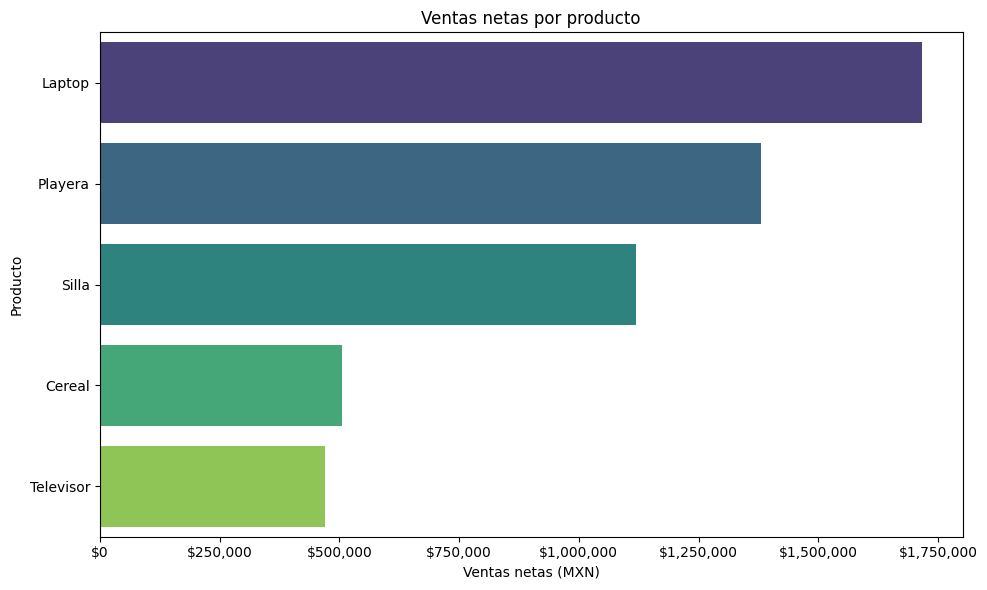

In [39]:
import matplotlib.ticker as mticker

def format_currency(x, pos):
    return f'${x:,.0f}'

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='ventas_netas', y='producto', data=ventas_producto, ax=ax, palette='viridis')
ax.set_title('Ventas netas por producto')
ax.set_xlabel('Ventas netas (MXN)')
ax.set_ylabel('Producto')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_currency))
plt.tight_layout()
plt.show()

/tmp/ipykernel_8427/1281001728.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ventas_netas', y='region', data=ventas_region, ax=ax, palette='viridis')


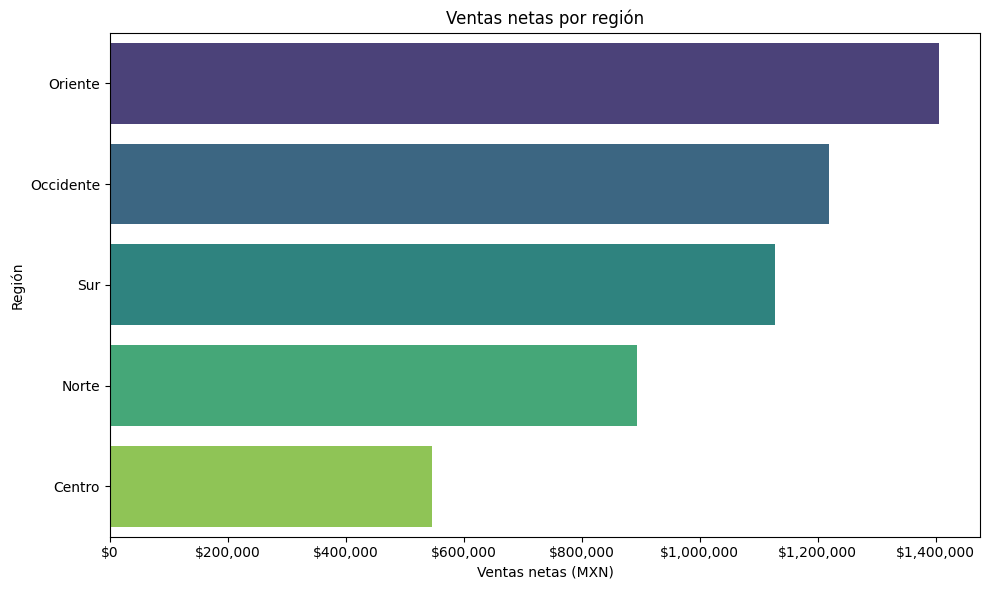

In [40]:
import matplotlib.ticker as mticker

def format_currency(x, pos):
    return f'${x:,.0f}'

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='ventas_netas', y='region', data=ventas_region, ax=ax, palette='viridis')
ax.set_title('Ventas netas por región')
ax.set_xlabel('Ventas netas (MXN)')
ax.set_ylabel('Región')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_currency))
plt.tight_layout()
plt.show()

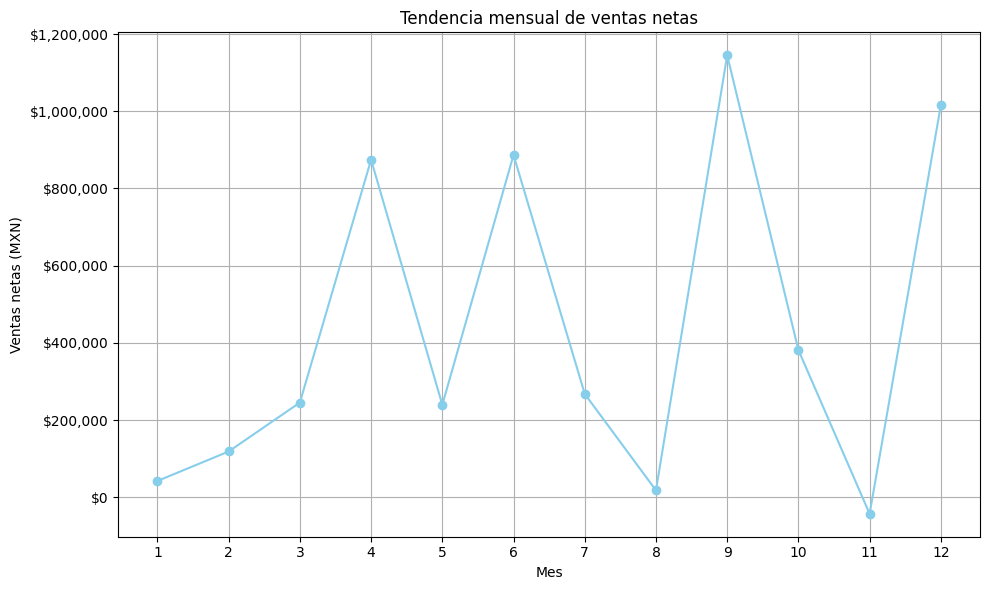

In [41]:
import matplotlib.ticker as mticker

def format_currency(x, pos):
    return f'${x:,.0f}'

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(ventas_mes['mes_num'], ventas_mes['ventas_netas'], marker='o', linestyle='-', color='skyblue')
ax.set_title('Tendencia mensual de ventas netas')
ax.set_xlabel('Mes')
ax.set_ylabel('Ventas netas (MXN)')
ax.set_xticks(range(1, 13))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(format_currency))
plt.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_8427/233647226.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ventas_netas', y='canal_venta', data=ventas_canal, ax=ax, palette='viridis')


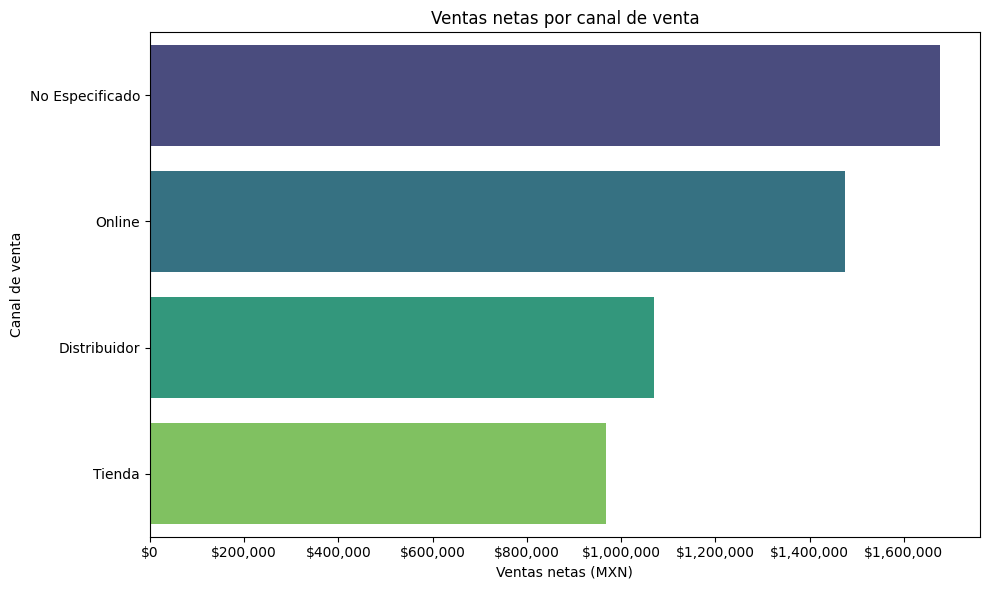

In [42]:
import matplotlib.ticker as mticker

def format_currency(x, pos):
    return f'${x:,.0f}'

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='ventas_netas', y='canal_venta', data=ventas_canal, ax=ax, palette='viridis')
ax.set_title('Ventas netas por canal de venta')
ax.set_xlabel('Ventas netas (MXN)')
ax.set_ylabel('Canal de venta')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_currency))
plt.tight_layout()
plt.show()

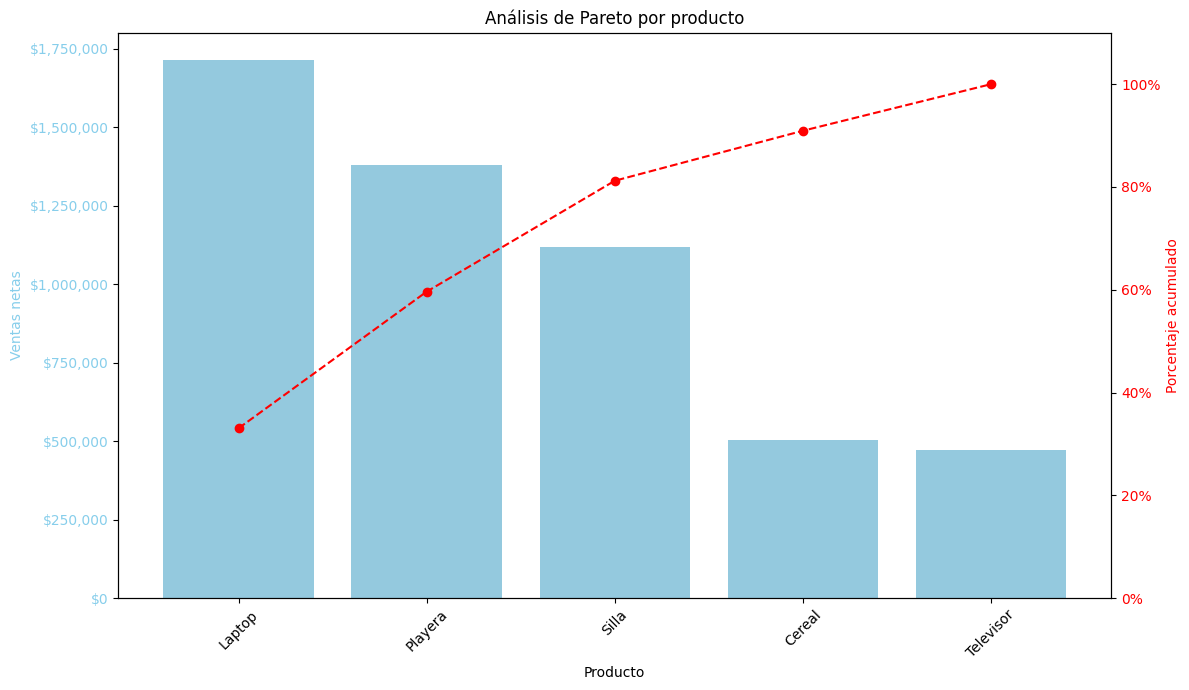

In [43]:
import matplotlib.ticker as mticker

def format_currency(x, pos):
    return f'${x:,.0f}'

def format_percent(x, pos):
    return f'{x:.0%}'

fig, ax1 = plt.subplots(figsize=(12, 7))

sns.barplot(x='producto', y='ventas_netas', data=pareto_producto, ax=ax1, color='skyblue')
ax1.set_xlabel('Producto')
ax1.set_ylabel('Ventas netas', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.xaxis.set_tick_params(rotation=45)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(format_currency))

ax2 = ax1.twinx()
ax2.plot(pareto_producto['producto'], pareto_producto['porcentaje_acumulado'], color='red', marker='o', linestyle='--')
ax2.set_ylabel('Porcentaje acumulado', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(format_percent))
ax2.set_ylim(0, 1.1)

plt.title('Análisis de Pareto por producto')
plt.tight_layout()
plt.show()